# ch226 — Simulation of Differential Systems

Most real systems are governed by **systems of ODEs** — multiple quantities evolving together, each influencing the others. Epidemic models, predator-prey dynamics, planetary orbits, neural firing — all are differential systems.

Numerical simulation *(ch225)* is how we extract behaviour from these equations.

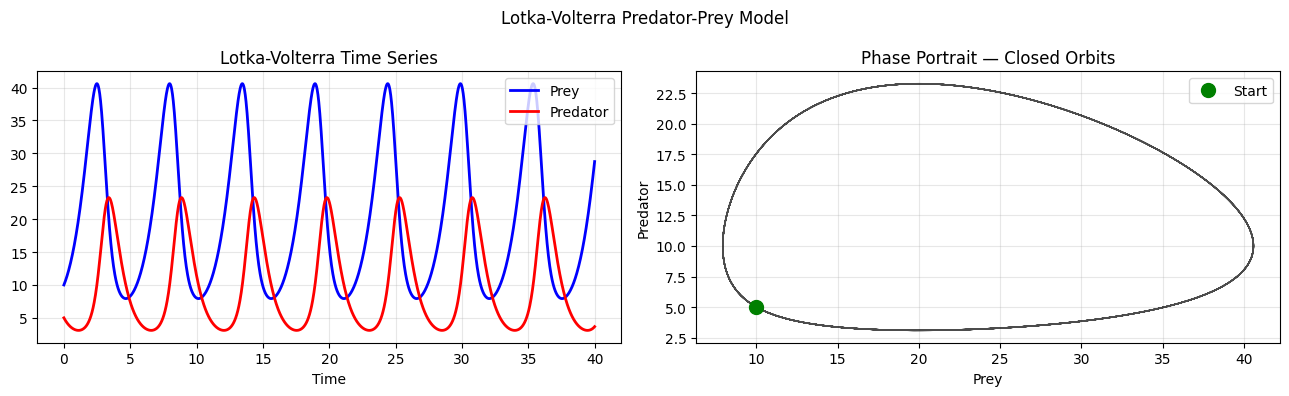

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ── Lotka-Volterra Predator-Prey Model ─────────────────────────────────────
# dx/dt = alpha*x - beta*x*y   (prey: grow, get eaten)
# dy/dt = delta*x*y - gamma*y  (predators: eat prey, die)

def lotka_volterra(t, state, alpha, beta, delta, gamma):
    x, y = state
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

params = dict(alpha=1.0, beta=0.1, delta=0.075, gamma=1.5)
y0 = [10.0, 5.0]  # initial prey=10, predator=5
t_span = (0, 40)
t_eval = np.linspace(0, 40, 2000)

sol = solve_ivp(lotka_volterra, t_span, y0, t_eval=t_eval, args=tuple(params.values()), rtol=1e-9)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sol.t, sol.y[0], 'b', lw=2, label='Prey')
axes[0].plot(sol.t, sol.y[1], 'r', lw=2, label='Predator')
axes[0].set_xlabel('Time'); axes[0].set_title('Lotka-Volterra Time Series')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(sol.y[0], sol.y[1], 'k', lw=1, alpha=0.7)
axes[1].plot(sol.y[0][0], sol.y[1][0], 'go', ms=10, label='Start')
axes[1].set_xlabel('Prey'); axes[1].set_ylabel('Predator')
axes[1].set_title('Phase Portrait — Closed Orbits')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('Lotka-Volterra Predator-Prey Model')
plt.tight_layout(); plt.savefig('ch226_lotka_volterra.png', dpi=100); plt.show()


## SIR Epidemic Model

Three populations: **S**usceptible, **I**nfected, **R**ecovered.

```
dS/dt = -beta*S*I
dI/dt = beta*S*I - gamma*I
dR/dt = gamma*I
```

This underpins the epidemiology of COVID-19, influenza, and all infectious diseases.

Basic reproduction number R0 = beta/gamma = 6.0
  R0 > 1: epidemic spreads. R0 < 1: epidemic dies out.


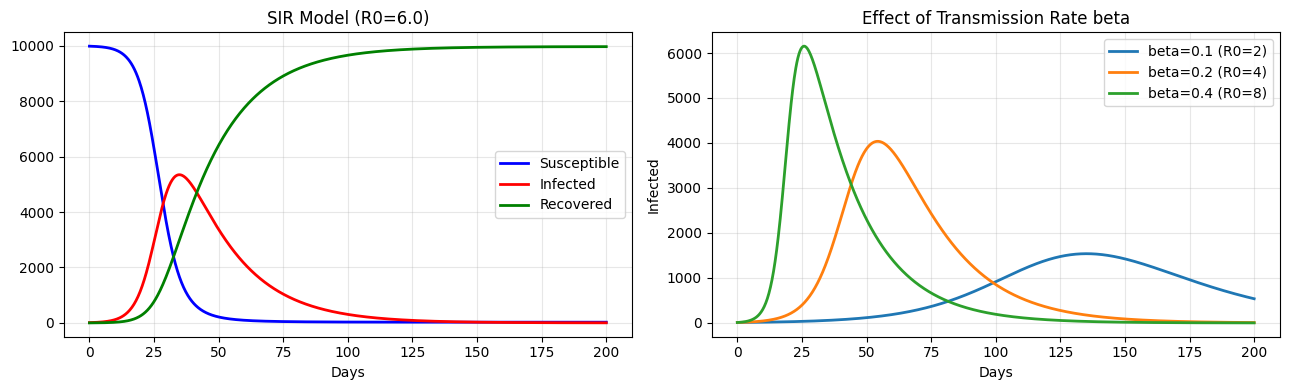

In [2]:
def sir_model(t, state, beta, gamma, N):
    S, I, R = state
    dS = -beta * S * I / N
    dI =  beta * S * I / N - gamma * I
    dR =  gamma * I
    return [dS, dI, dR]

N = 10_000
I0 = 10
S0 = N - I0
R0_val = 0  # recovered initially
beta, gamma = 0.3, 0.05
R_naught = beta / gamma
print(f"Basic reproduction number R0 = beta/gamma = {R_naught:.1f}")
print(f"  R0 > 1: epidemic spreads. R0 < 1: epidemic dies out.")

sol = solve_ivp(sir_model, (0, 200), [S0, I0, R0_val],
                args=(beta, gamma, N), t_eval=np.linspace(0, 200, 1000), rtol=1e-8)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sol.t, sol.y[0], 'b', lw=2, label='Susceptible')
axes[0].plot(sol.t, sol.y[1], 'r', lw=2, label='Infected')
axes[0].plot(sol.t, sol.y[2], 'g', lw=2, label='Recovered')
axes[0].set_xlabel('Days'); axes[0].set_title(f'SIR Model (R0={R_naught:.1f})')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Vary beta
for b, label in [(0.1, 'beta=0.1 (R0=2)'), (0.2, 'beta=0.2 (R0=4)'), (0.4, 'beta=0.4 (R0=8)')]:
    s = solve_ivp(sir_model, (0, 200), [S0, I0, 0], args=(b, gamma, N),
                  t_eval=np.linspace(0, 200, 1000), rtol=1e-8)
    axes[1].plot(s.t, s.y[1], lw=2, label=label)
axes[1].set_xlabel('Days'); axes[1].set_ylabel('Infected')
axes[1].set_title('Effect of Transmission Rate beta'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('ch226_sir.png', dpi=100); plt.show()


## Lorenz System — Deterministic Chaos

The Lorenz system is a 3D ODE that models atmospheric convection. It is deterministic yet exhibits **sensitive dependence on initial conditions** — the butterfly effect.

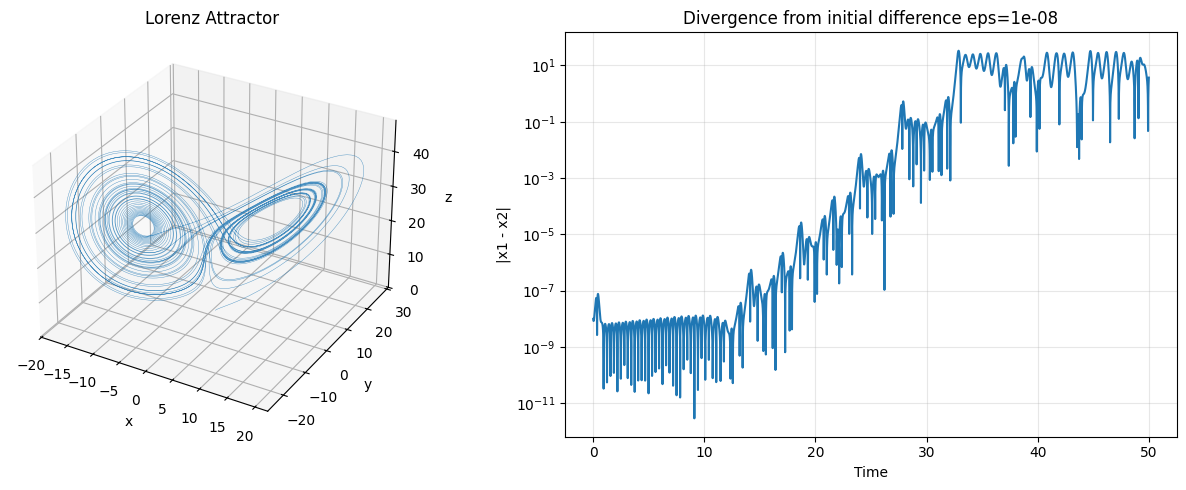

In [3]:
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    x, y, z = state
    return [sigma*(y-x), x*(rho-z)-y, x*y-beta*z]

# Two trajectories with imperceptibly different starting conditions
eps = 1e-8
sol1 = solve_ivp(lorenz, (0, 50), [1.0, 1.0, 1.0],    t_eval=np.linspace(0, 50, 10000), rtol=1e-10)
sol2 = solve_ivp(lorenz, (0, 50), [1.0+eps, 1.0, 1.0], t_eval=np.linspace(0, 50, 10000), rtol=1e-10)

fig = plt.figure(figsize=(13, 5))
ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot(sol1.y[0], sol1.y[1], sol1.y[2], lw=0.3, alpha=0.8)
ax3d.set_title('Lorenz Attractor'); ax3d.set_xlabel('x'); ax3d.set_ylabel('y'); ax3d.set_zlabel('z')

ax2 = fig.add_subplot(122)
diff = np.abs(sol1.y[0] - sol2.y[0])
ax2.semilogy(sol1.t, diff)
ax2.set_xlabel('Time'); ax2.set_ylabel('|x1 - x2|')
ax2.set_title(f'Divergence from initial difference eps={eps}')
ax2.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.savefig('ch226_lorenz.png', dpi=100); plt.show()


## Summary

| System | Key Feature |
|---|---|
| Lotka-Volterra | Coupled oscillations, closed orbits |
| SIR model | Threshold dynamics (R0 = 1) |
| Lorenz attractor | Deterministic chaos, sensitive dependence |
| Damped oscillator | Energy dissipation, equilibrium approach |

**Forward reference:** ch227 — Gradient-Based Learning reframes neural network training as a flow in a high-dimensional space, governed by the gradient differential equation dw/dt = -grad L(w).